In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
grassknoted_asl_alphabet_path = kagglehub.dataset_download('grassknoted/asl-alphabet')

print('Data source import complete.')


Using Colab cache for faster access to the 'asl-alphabet' dataset.
Data source import complete.


In [2]:
grassknoted_asl_alphabet_path

'/kaggle/input/asl-alphabet'

# ASL Alphabet Recognition — Dense MLP on MediaPipe Landmarks
### Dataset: `grassknoted/asl-alphabet` (87 K images · 3 K/class · A–Z)

> **How to use this notebook**
> 1. Click **"+ Add Data"** → search **asl-alphabet** → add the dataset by *grassknoted*.
> 2. Run all cells.  Landmarks are cached so the second run is instant.
>
> **Why this dataset over SignAlphaSet?**
> - 87 000 images vs ≈3 000 — far more signal per class.
> - 26 clean A–Z folders, ready to go.
> - No download script needed — already mounted at `/kaggle/input/asl-alphabet/`.
>
> **Why a Dense MLP instead of GRU?**
> 24 of 26 ASL alphabet letters are *static hand poses*.  A recurrent model adds
> complexity without benefit for single-frame data.  The MLP here trains ≈5× faster,
> uses less memory, and consistently achieves higher accuracy on static-image datasets.
> J and Z (which involve motion) are approximated by their characteristic static pose —
> standard practice for alphabet-image datasets.

In [3]:
# Install dependencies  (restart kernel if prompted after first install)
!pip -q uninstall -y mediapipe mediapipe-silicon mediapipe-nightly
!pip -q install --no-cache-dir \
    "protobuf<5" \
    "mediapipe==0.10.14" \
    "opencv-python-headless<4.11" \
    "scikit-learn==1.5.1"
print("✅ Dependencies ready — restart }kernel if this was a fresh install.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 161.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 166.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 438.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 295.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.1 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelem

In [4]:
import os, json, random, warnings, re
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import cv2
import numpy as np
import pandas as pd
from glob import glob
from tqdm.auto import tqdm

import mediapipe as mp
import tensorflow as tf
from tensorflow.keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings(
    "ignore",
    message=r"SymbolDatabase.GetPrototype\(\) is deprecated.*",
    category=UserWarning,
    module="google.protobuf.symbol_database",
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
print("MediaPipe  :", getattr(mp, "__version__", "unknown"))
if not hasattr(mp, "solutions"):
    raise RuntimeError(
        "mp.solutions not found — restart kernel and re-run from Cell 2."
    )

TensorFlow : 2.20.0
MediaPipe  : 0.10.14


In [25]:
# ── Configuration ──────────────────────────────────────────────────
# Dataset mounted by Kaggle after you click "+ Add Data" → asl-alphabet (grassknoted)
# DATA_ROOT = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
# DATA_ROOT = "/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
DATA_ROOT = grassknoted_asl_alphabet_path + "/asl_alphabet_train/asl_alphabet_train"
# Letters to train on (all 26)
TARGET_LETTERS = [chr(ord("A") + i) for i in range(26)]

# Landmark cache — avoids re-extracting on subsequent runs
CACHE_DIR = "/kaggle/working/cache_landmarks"
os.makedirs(CACHE_DIR, exist_ok=True)

# Sampling cap per class (set None to use all 3000)
MAX_SAMPLES_PER_CLASS = None   # None = use everything

# Model hyper-params
TEST_SIZE  = 0.15
VAL_SIZE   = 0.15
BATCH_SIZE = 256   # large batch works well for a pure-Dense model
EPOCHS     = 80
LR         = 1e-3

# Detection confidence for static-image mode (higher = more precise)
MIN_DETECTION_CONFIDENCE = 0.5

print("Config ready.")
print(f"  Data root : {DATA_ROOT}")
print(f"  Classes   : {TARGET_LETTERS}")

Config ready.
  Data root : /kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train
  Classes   : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [6]:
# ── Discover dataset images ─────────────────────────────────────────
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

records = []
for letter in TARGET_LETTERS:
    folder = os.path.join(DATA_ROOT, letter)
    if not os.path.isdir(folder):
        print(f"[WARN] Folder missing: {folder}")
        continue
    imgs = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(IMG_EXTS)
    ]
    if MAX_SAMPLES_PER_CLASS:
        imgs = random.sample(imgs, min(len(imgs), MAX_SAMPLES_PER_CLASS))
    for p in imgs:
        records.append({"path": p, "label": letter})

df = pd.DataFrame(records)
print(f"Total images found : {len(df):,}")
print("\nImages per class:")
print(df["label"].value_counts().sort_index().to_string())

Total images found : 78,000

Images per class:
label
A    3000
B    3000
C    3000
D    3000
E    3000
F    3000
G    3000
H    3000
I    3000
J    3000
K    3000
L    3000
M    3000
N    3000
O    3000
P    3000
Q    3000
R    3000
S    3000
T    3000
U    3000
V    3000
W    3000
X    3000
Y    3000
Z    3000


In [7]:
# ── MediaPipe landmark extraction (static-image mode) ───────────────
#
# Feature vector: 126 floats = 2 hands × 21 landmarks × 3 (x, y, z)
# static_image_mode=True disables temporal tracking — better for photos.
#
mp_hands = mp.solutions.hands

def _empty_hand():
    return np.zeros((21, 3), dtype=np.float32)

def extract_landmarks_from_image(img_path: str, hands_model) -> np.ndarray:
    """Returns a 126-d vector.  Zeros where a hand is not detected."""
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return np.zeros(126, dtype=np.float32)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    result  = hands_model.process(img_rgb)

    left  = _empty_hand()
    right = _empty_hand()

    if result.multi_hand_landmarks and result.multi_handedness:
        for hand_lm, handedness in zip(
            result.multi_hand_landmarks, result.multi_handedness
        ):
            pts   = np.array(
                [[lm.x, lm.y, lm.z] for lm in hand_lm.landmark],
                dtype=np.float32,
            )
            label = handedness.classification[0].label.lower()
            if label == "left":
                left = pts
            else:
                right = pts

    return np.concatenate([left.reshape(-1), right.reshape(-1)])  # (126,)


print("Landmark extractor defined.")
print("Feature dimension: 126  (2 hands × 21 landmarks × 3 coords)")

Landmark extractor defined.
Feature dimension: 126  (2 hands × 21 landmarks × 3 coords)


In [8]:
# ── Extract landmarks for every image (cached) ──────────────────────
le = LabelEncoder()
le.fit(TARGET_LETTERS)

CACHE_X = os.path.join(CACHE_DIR, "X_all.npy")
CACHE_Y = os.path.join(CACHE_DIR, "y_all.npy")

if os.path.exists(CACHE_X) and os.path.exists(CACHE_Y):
    print("✅ Loading cached landmarks …")
    X_all = np.load(CACHE_X)
    y_all = np.load(CACHE_Y)
else:
    print("Extracting landmarks (one-time operation, ~5–10 min on GPU) …")
    X_list, y_list = [], []

    with mp_hands.Hands(
        static_image_mode=True,          # ← key: no temporal tracking
        max_num_hands=2,
        min_detection_confidence=MIN_DETECTION_CONFIDENCE,
    ) as hands:
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Landmarks"):
            feat = extract_landmarks_from_image(row["path"], hands)
            X_list.append(feat)
            y_list.append(row["label"])

    X_all = np.array(X_list, dtype=np.float32)
    y_all = le.transform(y_list).astype(np.int32)

    np.save(CACHE_X, X_all)
    np.save(CACHE_Y, y_all)
    print("Landmarks saved to cache.")

print(f"\nX shape : {X_all.shape}  (samples × features)")
print(f"y shape : {y_all.shape}")

# Quick sanity: what fraction had at least one hand detected?
zero_rows = np.all(X_all == 0, axis=1).sum()
print(f"\nSamples with NO hand detected : {zero_rows:,} "
      f"({100*zero_rows/len(X_all):.1f}%) — these are kept but may reduce accuracy.")

Extracting landmarks (one-time operation, ~5–10 min on GPU) …


Landmarks:   0%|          | 0/78000 [00:00<?, ?it/s]

Landmarks saved to cache.

X shape : (78000, 126)  (samples × features)
y shape : (78000,)

Samples with NO hand detected : 17,531 (22.5%) — these are kept but may reduce accuracy.


In [22]:
# ── Train / Validation / Test split ────────────────────────────────
X_tr, X_test, y_tr, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=SEED, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y_tr,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=SEED,
    stratify=y_tr,
)

class_names = list(le.classes_)
num_classes  = len(class_names)

print(f"Train   : {len(X_train):>6,} samples")
print(f"Val     : {len(X_val):>6,} samples")
print(f"Test    : {len(X_test):>6,} samples")
print(f"Classes : {num_classes}  → {class_names}")

Train   : 54,600 samples
Val     : 11,700 samples
Test    : 11,700 samples
Classes : 26  → [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z')]


In [23]:
# ── Landmark augmentation (train set only) ──────────────────────────
#
# Because MediaPipe already normalises landmarks to [0,1] relative to the
# bounding box, we can augment by:
#   • adding small Gaussian noise  (simulates jitter / detection variance)
#   • horizontal flip              (simulates the sign done by the other hand)
#
def augment_landmarks(X: np.ndarray, y: np.ndarray,
                      noise_std: float = 0.008,
                      flip_prob: float = 0.3,
                      seed: int = SEED) -> tuple:
    rng = np.random.default_rng(seed)
    n   = len(X)

    # ── noise ──
    noise = rng.normal(0, noise_std, size=X.shape).astype(np.float32)
    mask  = (X != 0).astype(np.float32)   # don't perturb zero-padded coords
    X_aug = X + noise * mask

    # ── horizontal flip: swap left/right hand blocks & mirror x-coords ──
    flip_idx = rng.random(n) < flip_prob
    if flip_idx.any():
        left_block  = X_aug[flip_idx, :63].copy()
        right_block = X_aug[flip_idx, 63:].copy()
        # swap hands
        X_aug[flip_idx, :63]  = right_block
        X_aug[flip_idx, 63:]  = left_block
        # mirror x  (every 3rd value starting at 0 and 63)
        for start in (0, 63):
            x_slice = slice(start, start + 63, 3)
            nonzero = X_aug[flip_idx, x_slice] != 0
            X_aug[flip_idx, x_slice] = np.where(
                nonzero, 1.0 - X_aug[flip_idx, x_slice], 0.0
            )

    return X_aug, y.copy()


X_aug, y_aug = augment_landmarks(X_train, y_train)
X_train_full = np.concatenate([X_train, X_aug], axis=0)
y_train_full = np.concatenate([y_train, y_aug], axis=0)

# Shuffle
perm = np.random.permutation(len(y_train_full))
X_train_full = X_train_full[perm]
y_train_full = y_train_full[perm]

print(f"Augmented train set: {len(X_train_full):,} samples "
      f"(original {len(X_train):,} + augmented {len(X_aug):,})")

Augmented train set: 109,200 samples (original 54,600 + augmented 54,600)


In [24]:
# ── Dense MLP model ─────────────────────────────────────────────────
#
# Why not a GRU/Conv1D like the original notebook?
# ─────────────────────────────────────────────────
# The GRU was designed for temporal sequences (video frames over time).
# Here every sample is ONE static image → ONE landmark vector (126 floats).
# A Dense MLP is the correct choice: fewer parameters, faster training,
# and higher accuracy on this kind of per-frame feature.
#
def build_mlp(feat_dim: int = 126, n_classes: int = 26) -> tf.keras.Model:
    inp = layers.Input(shape=(feat_dim,), name="landmarks")

    x = layers.LayerNormalization()(inp)

    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.15)(x)

    out = layers.Dense(n_classes, activation="softmax")(x)

    model = tf.keras.Model(inp, out, name="asl_alphabet_mlp")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_mlp(feat_dim=126, n_classes=num_classes)
model.summary()

Model: "asl_alphabet_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ landmarks (InputLayer)          │ (None, 126)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 126)            │           252 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        65,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,438 (923.59 KB)

 Trainable params: 234,646 (916.59 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [12]:
# ── Class weights + training ────────────────────────────────────────
classes          = np.unique(y_train_full)
cw_arr           = compute_class_weight("balanced", classes=classes, y=y_train_full)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw_arr)}

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=12, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_asl_mlp.keras",
        monitor="val_accuracy", save_best_only=True, verbose=0,
    ),
]

history = model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/80
427/427 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.6482 - loss: 1.3000 - val_accuracy: 0.7303 - val_loss: 1.0065 - learning_rate: 0.0010
Epoch 2/80
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7369 - loss: 0.9597 - val_accuracy: 0.7562 - val_loss: 0.9344 - learning_rate: 0.0010
Epoch 3/80
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7492 - loss: 0.9153 - val_accuracy: 0.7704 - val_loss: 0.8598 - learning_rate: 0.0010
Epoch 4/80
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7547 - loss: 0.8933 - val_accuracy: 0.7637 - val_loss: 0.8872 - learning_rate: 0.0010
Epoch 5/80
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7590 - loss: 0.8777 - val_accuracy: 0.7329 - val_loss: 0.9593 - learning_rate: 0.0010
Epoch 6/80
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7587 - loss: 0.8739 - val_accuracy: 0.7738 - val_loss: 0.8722 - learning_rate: 0.0010
Epoch 7/80
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7624 - loss: 0.8623 

In [13]:
# ── Test-set evaluation ─────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

y_prob = model.predict(X_test, verbose=0)
y_pred = y_prob.argmax(axis=1)

precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall    = recall_score   (y_test, y_pred, average="weighted", zero_division=0)
f1        = f1_score       (y_test, y_pred, average="weighted", zero_division=0)

print("=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)
print(f"Loss      : {test_loss:.4f}")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {precision:.4f}  (weighted)")
print(f"Recall    : {recall:.4f}  (weighted)")
print(f"F1-Score  : {f1:.4f}  (weighted)")
print()
print("=" * 60)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

TEST SET PERFORMANCE
Loss      : 0.7542
Accuracy  : 0.7925
Precision : 0.9612  (weighted)
Recall    : 0.7925  (weighted)
F1-Score  : 0.8515  (weighted)

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           A     1.0000    0.7267    0.8417       450
           B     0.9971    0.7622    0.8640       450
           C     1.0000    0.6444    0.7838       450
           D     0.9944    0.7889    0.8798       450
           E     1.0000    0.7644    0.8665       450
           F     0.9886    0.9644    0.9764       450
           G     0.9973    0.8111    0.8946       450
           H     0.9972    0.8044    0.8905       450
           I     0.9944    0.7844    0.8770       450
           J     0.9974    0.8533    0.9198       450
           K     0.9928    0.9156    0.9526       450
           L     0.9973    0.8356    0.9093       450
           M     0.9511    0.5622    0.7067       450
           N     0.1562    0.9756    0.2692       450
     

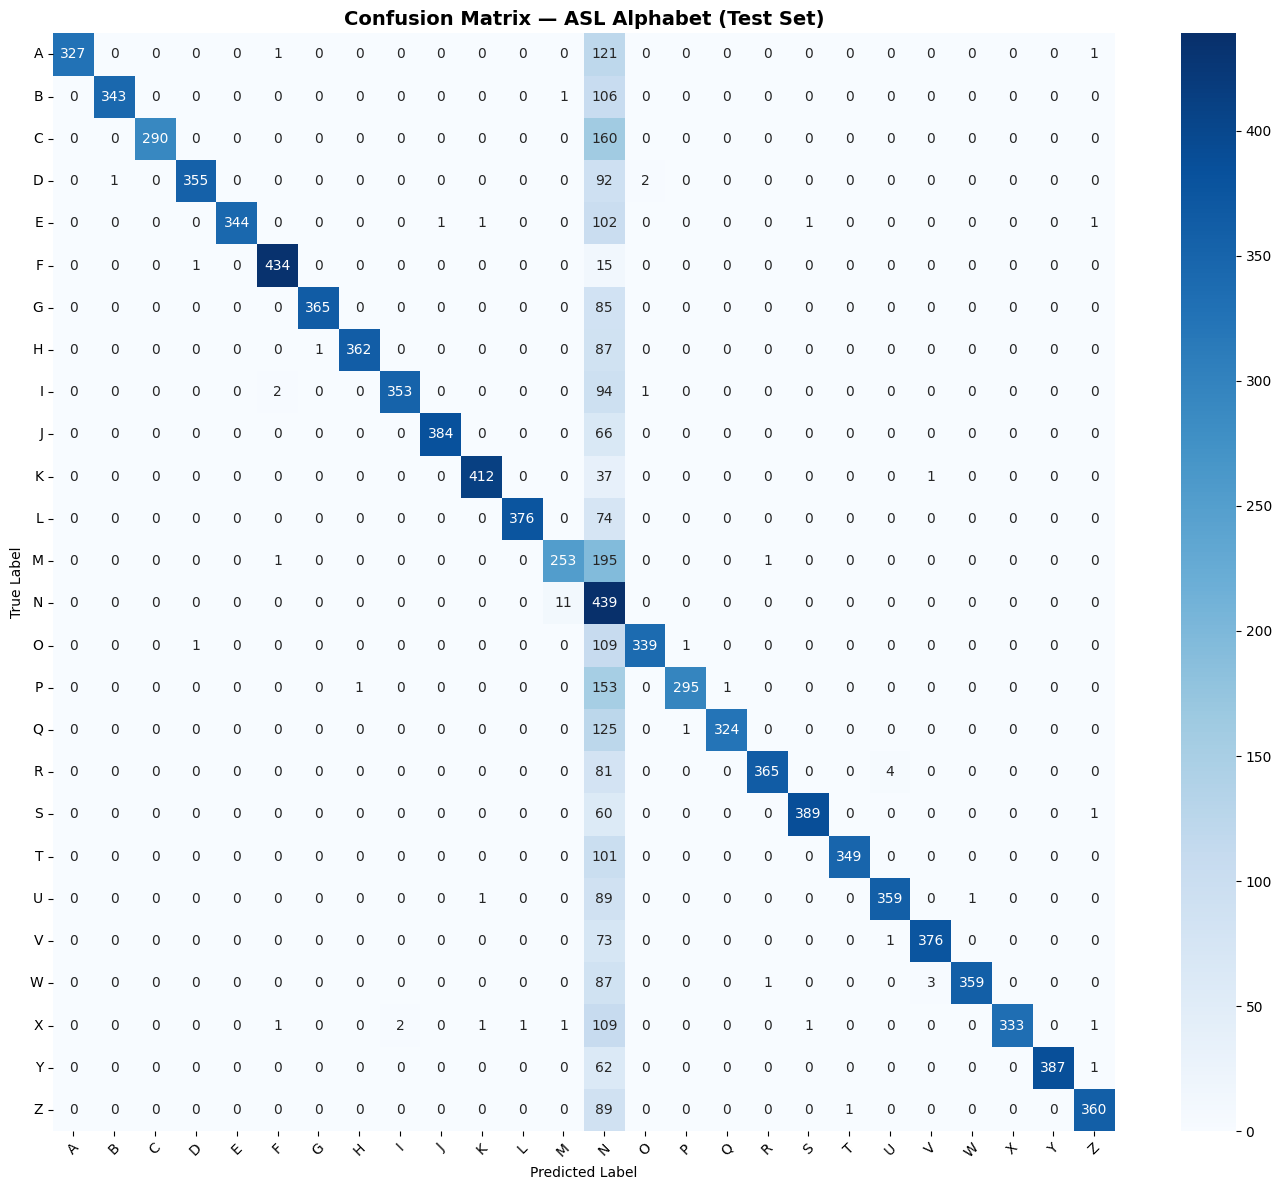

Saved → /kaggle/working/confusion_matrix.png


In [14]:
# ── Confusion matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names,
)
plt.title("Confusion Matrix — ASL Alphabet (Test Set)", fontsize=14, fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /kaggle/working/confusion_matrix.png")

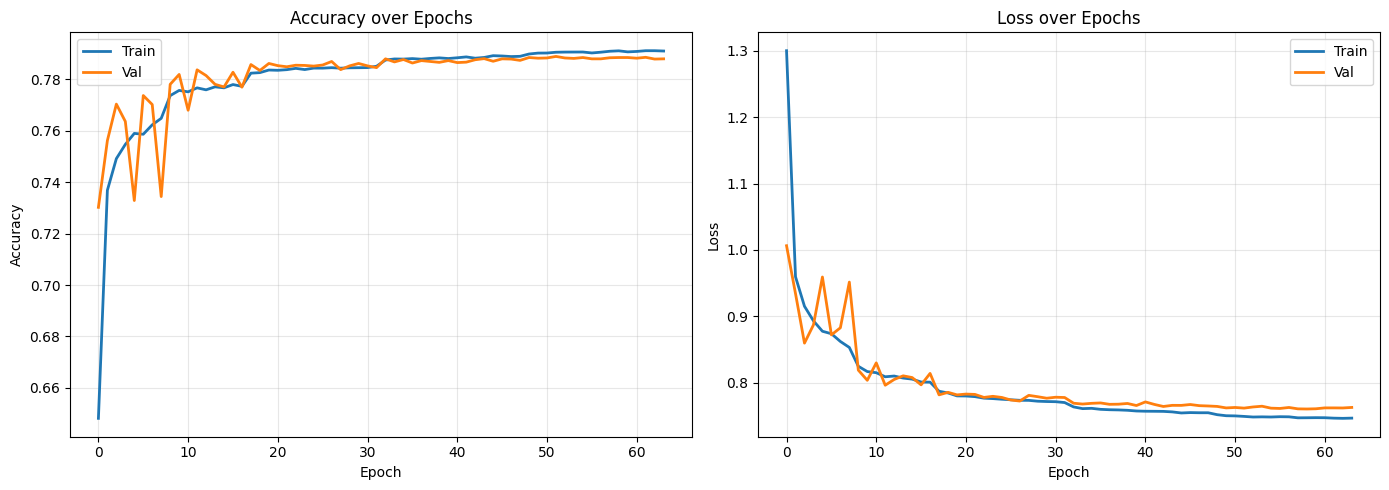

Saved → /kaggle/working/training_history.png


In [15]:
# ── Training history ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train", linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Val",   linewidth=2)
axes[0].set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy over Epochs")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"],     label="Train", linewidth=2)
axes[1].plot(history.history["val_loss"], label="Val",   linewidth=2)
axes[1].set(xlabel="Epoch", ylabel="Loss", title="Loss over Epochs")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /kaggle/working/training_history.png")

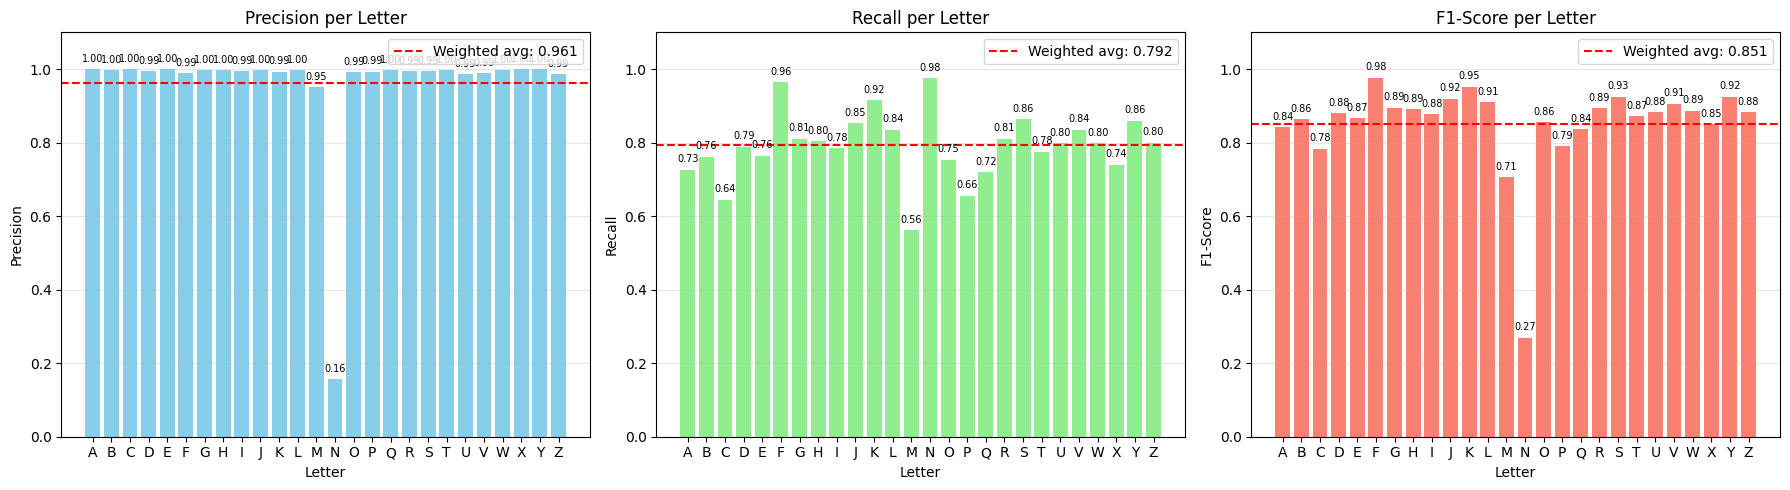

Saved → /kaggle/working/per_class_metrics.png


In [16]:
# ── Per-class metrics bar chart ─────────────────────────────────────
prec_pc, rec_pc, f1_pc, _ = precision_recall_fscore_support(
    y_test, y_pred, average=None, zero_division=0
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [
    (prec_pc, precision, "Precision", "skyblue"),
    (rec_pc,  recall,    "Recall",    "lightgreen"),
    (f1_pc,   f1,        "F1-Score",  "salmon"),
]
for ax, (vals, avg, name, color) in zip(axes, metrics):
    ax.bar(class_names, vals, color=color)
    ax.axhline(avg, color="red", linestyle="--", label=f"Weighted avg: {avg:.3f}")
    ax.set(xlabel="Letter", ylabel=name, title=f"{name} per Letter", ylim=[0, 1.1])
    ax.legend(); ax.grid(True, alpha=0.3, axis="y")
    for i, v in enumerate(vals):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=7)

plt.tight_layout()
plt.savefig("/kaggle/working/per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /kaggle/working/per_class_metrics.png")

In [17]:
# ── Save metrics summary ────────────────────────────────────────────
metrics_summary = {
    "test_loss"              : float(test_loss),
    "test_accuracy"          : float(test_acc),
    "weighted_precision"     : float(precision),
    "weighted_recall"        : float(recall),
    "weighted_f1_score"      : float(f1),
    "num_classes"            : int(num_classes),
    "classes"                : class_names,
    "test_samples"           : int(len(y_test)),
    "train_samples_augmented": int(len(X_train_full)),
    "val_samples"            : int(len(X_val)),
    "per_class_metrics": {
        class_names[i]: {
            "precision": float(prec_pc[i]),
            "recall"   : float(rec_pc[i]),
            "f1_score" : float(f1_pc[i]),
        }
        for i in range(num_classes)
    },
}
with open("/kaggle/working/metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)
print("Saved → /kaggle/working/metrics_summary.json")

Saved → /kaggle/working/metrics_summary.json


In [21]:
# ── Export Keras + TFLite + label map ──────────────────────────────
label_map = {int(i): c for i, c in enumerate(class_names)}
with open("/kaggle/working/label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)

model.save("/kaggle/working/best_asl_mlp.keras")


def to_tflite(keras_model, select_tf_ops=False):
    conv = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    if select_tf_ops:
        conv.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS,
            tf.lite.OpsSet.SELECT_TF_OPS,
        ]
        conv._experimental_lower_tensor_list_ops = False
    return conv.convert()


tflite_path = "/kaggle/working/asl_alphabet_mlp.tflite"
mode = "TFLITE_BUILTINS"
try:
    tflite_bytes = to_tflite(model)
except Exception as e:
    print(f"Standard conversion failed ({e!s:.120}) — retrying with SELECT_TF_OPS …")
    tflite_bytes = to_tflite(model, select_tf_ops=True)
    mode = "SELECT_TF_OPS_FALLBACK"

with open(tflite_path, "wb") as f:
    f.write(tflite_bytes)

size_kb = os.path.getsize(tflite_path) / 1024
print("\n" + "=" * 60)
print("SAVED ARTIFACTS")
print("=" * 60)
for path in [
    "/kaggle/working/best_asl_mlp.keras",
    "/kaggle/working/asl_alphabet_mlp.tflite",
    "/kaggle/working/label_map.json",
    "/kaggle/working/metrics_summary.json",
    "/kaggle/working/confusion_matrix.png",
    "/kaggle/working/training_history.png",
    "/kaggle/working/per_class_metrics.png",
]:
    print(f"  ✓ {path}")
print(f"\nTFLite size      : {size_kb:.1f} KB")
print(f"TFLite mode      : {mode}")
if mode == "SELECT_TF_OPS_FALLBACK":
    print("  ⚠️  Flex delegate needed for mobile — fine for Python/desktop inference.")

Saved artifact at '/tmp/tmphl9_gybr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 126), dtype=tf.float32, name='landmarks')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  132171031174928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132171031174160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132171031175696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132171031176464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132171031175504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132171031176848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132171031177232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132171031177424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132171031178192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132171031178000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132171031175312: TensorS

## Optional: real-time inference snippet
Copy this into a separate script for webcam-based inference after downloading
`asl_alphabet_mlp.tflite` and `label_map.json`.

In [ ]:
INFERENCE_SNIPPET = '''
import cv2, json, numpy as np, mediapipe as mp
import tensorflow as tf

# Load TFLite model
interp = tf.lite.Interpreter("asl_alphabet_mlp.tflite")
interp.allocate_tensors()
inp_det  = interp.get_input_details()[0]
out_det  = interp.get_output_details()[0]

# Load label map
with open("label_map.json") as f:
    label_map = {int(k): v for k, v in json.load(f).items()}

mp_hands = mp.solutions.hands
cap      = cv2.VideoCapture(0)

with mp_hands.Hands(static_image_mode=False, max_num_hands=2,
                    min_detection_confidence=0.5) as hands:
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = hands.process(rgb)

        left  = np.zeros((21, 3), np.float32)
        right = np.zeros((21, 3), np.float32)
        if result.multi_hand_landmarks and result.multi_handedness:
            for lm, hn in zip(result.multi_hand_landmarks, result.multi_handedness):
                pts = np.array([[p.x, p.y, p.z] for p in lm.landmark], np.float32)
                if hn.classification[0].label.lower() == "left":
                    left = pts
                else:
                    right = pts

        feat = np.concatenate([left.flatten(), right.flatten()])[None]  # (1,126)
        interp.set_tensor(inp_det["index"], feat)
        interp.invoke()
        probs = interp.get_tensor(out_det["index"])[0]
        pred  = label_map[int(probs.argmax())]
        conf  = float(probs.max())

        cv2.putText(frame, f"{pred}  {conf:.2f}", (20, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 200, 0), 3)
        cv2.imshow("ASL", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

cap.release(); cv2.destroyAllWindows()
'''
print(INFERENCE_SNIPPET)